In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Conexión a la base de datos
engine = create_engine('sqlite:///../data/superstore.db')


In [4]:
query = """
SELECT Category, 
       ROUND(SUM(Sales), 2) AS total_ventas
FROM ventas
GROUP BY Category
ORDER BY total_ventas DESC;
"""

df = pd.read_sql(query, engine)
print(df)

          Category  total_ventas
0       Technology     827455.87
1        Furniture     728658.58
2  Office Supplies     705422.33


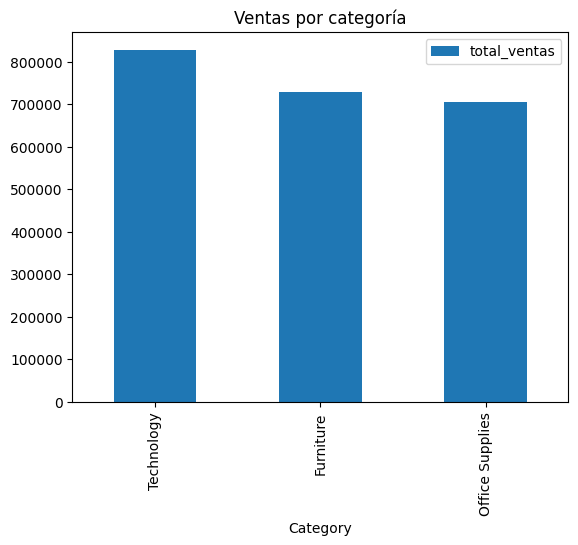

In [5]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='Category', y='total_ventas')
plt.title('Ventas por categoría')
plt.show()

In [6]:
query = """
SELECT "Product Name", 
       ROUND(SUM(Sales), 2) AS total_ventas
FROM ventas
GROUP BY "Product Name"
ORDER BY total_ventas DESC
LIMIT 5;
"""

df_top_productos = pd.read_sql(query, engine)
df_top_productos

,Product Name,total_ventas
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48


In [7]:
query = """
SELECT Region, 
       ROUND(SUM(Sales), 2) AS total_ventas,
       COUNT(*) AS cantidad_ordenes
FROM ventas
GROUP BY Region
ORDER BY total_ventas DESC;
"""

df_region = pd.read_sql(query, engine)
df_region

,Region,total_ventas,cantidad_ordenes
0,West,710219.68,3140
1,East,669518.73,2785
2,Central,492646.91,2277
3,South,389151.46,1598


In [8]:
query = """
SELECT City,
       ROUND(SUM(Sales), 2) AS total_ventas
FROM ventas
GROUP BY City
ORDER BY total_ventas DESC
LIMIT 10;
"""

df_ciudades = pd.read_sql(query, engine)
df_ciudades

,City,total_ventas
0,New York City,252462.55
1,Los Angeles,173420.18
2,Seattle,116106.32
3,San Francisco,109041.12
4,Philadelphia,108841.75
5,Houston,63956.14
6,Chicago,47820.13
7,San Diego,47521.03
8,Jacksonville,44713.18
9,Detroit,42446.94


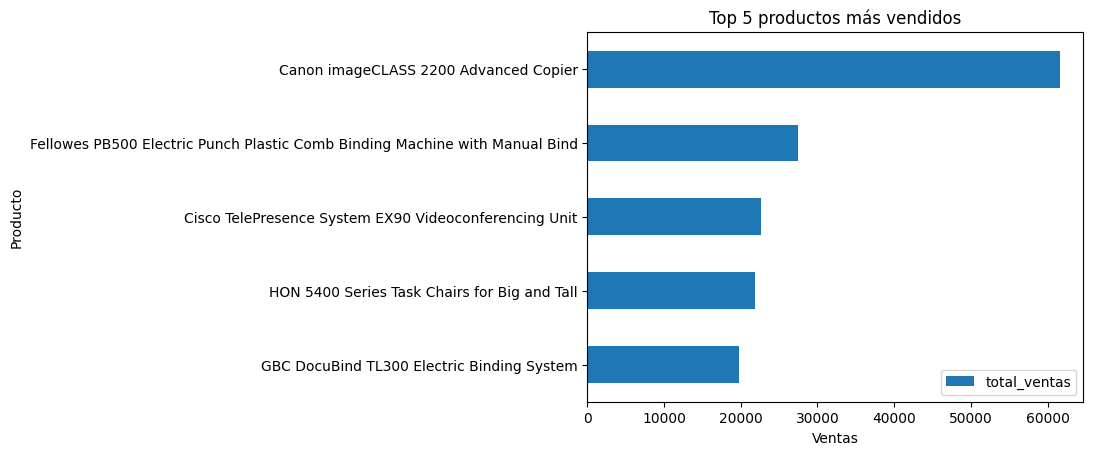

In [9]:
import matplotlib.pyplot as plt

df_top_productos.plot(
    kind='barh',
    x='Product Name',
    y='total_ventas'
)

plt.title('Top 5 productos más vendidos')
plt.xlabel('Ventas')
plt.ylabel('Producto')
plt.gca().invert_yaxis()
plt.show()

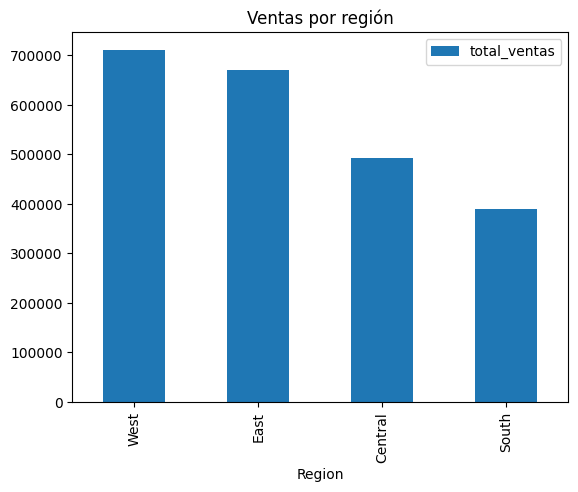

In [10]:
df_region.plot(
    kind='bar',
    x='Region',
    y='total_ventas'
)

plt.title('Ventas por región')
plt.show()

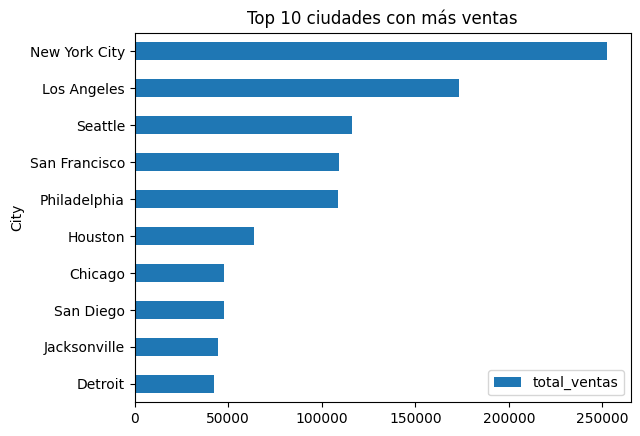

In [11]:
df_ciudades.plot(
    kind='barh',
    x='City',
    y='total_ventas'
)

plt.title('Top 10 ciudades con más ventas')
plt.gca().invert_yaxis()
plt.show()

In [12]:
df.describe()

,total_ventas
count,3.000000
mean,753845.593333
std,64798.421676
min,705422.330000
25%,717040.455000
50%,728658.580000
75%,778057.225000
max,827455.870000


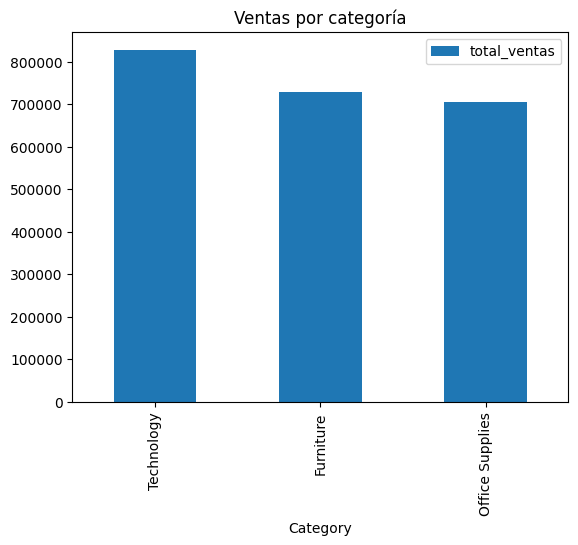

In [13]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='Category', y='total_ventas')
plt.title('Ventas por categoría')

plt.savefig('../imagenes/ventas_por_categoria.png')  # 👈 guarda la imagen
plt.show()

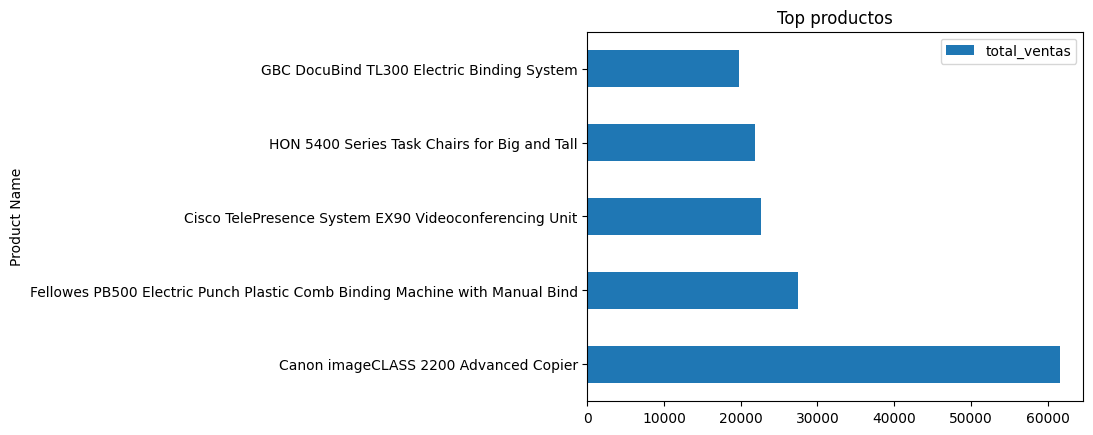

In [14]:
df_top_productos.plot(kind='barh', x='Product Name', y='total_ventas')

plt.title('Top productos')
plt.savefig('../imagenes/top_productos.png')
plt.show()

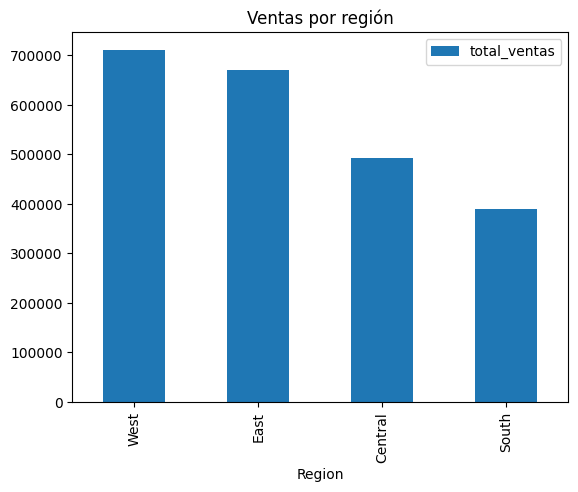

In [15]:
df_region.plot(kind='bar', x='Region', y='total_ventas')

plt.title('Ventas por región')
plt.savefig('../imagenes/ventas_region.png')
plt.show()

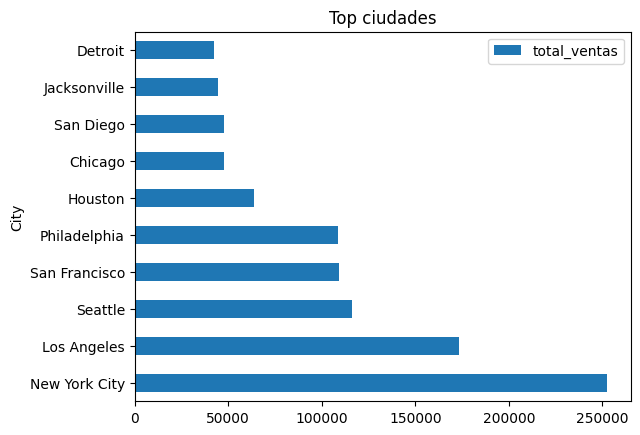

In [16]:
df_ciudades.plot(kind='barh', x='City', y='total_ventas')

plt.title('Top ciudades')
plt.savefig('../imagenes/top_ciudades.png')
plt.show()